# Final Model Comparison

This notebook combines all model prediction files and creates the final comparison plot.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from forecast_utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

files = ['persistence', 'arima', 'xgboost', 'lstm']
merged = None
for name in files:
    path = OUTPUT_DIR / f'{name}_predictions.csv'
    temp = pd.read_csv(path, parse_dates=['timestamp'])
    temp = temp.rename(columns={'actual': f'actual_{name}'})
    keep = ['timestamp', f'actual_{name}', name]
    if merged is None:
        merged = temp[keep].rename(columns={f'actual_{name}': 'actual'})
    else:
        merged = pd.merge_asof(merged.sort_values('timestamp'), temp[keep].sort_values('timestamp'), on='timestamp', direction='nearest')
        merged = merged.drop(columns=[f'actual_{name}'])
merged = merged.dropna()
merged.head()

,timestamp,actual,persistence,arima,xgboost,lstm
0,2019-05-25 19:10:00,0.007260,0.001484,0.001318,0.018560,0.004877
1,2019-05-25 19:15:00,0.013036,0.007260,0.001249,0.018560,0.008903
2,2019-05-25 19:20:00,0.018813,0.013036,0.001250,0.018560,0.012782
3,2019-05-25 19:25:00,0.024589,0.018813,0.001279,0.024508,0.016649
4,2019-05-25 19:30:00,0.030365,0.024589,0.001297,0.026346,0.020510


In [2]:
metrics = []
for name in files:
    mse = mean_squared_error(merged['actual'], merged[name])
    metrics.append({
        'model': name,
        'MAE': mean_absolute_error(merged['actual'], merged[name]),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(merged['actual'], merged[name]),
    })
metrics_df = pd.DataFrame(metrics).sort_values('RMSE')
metrics_df.to_csv(OUTPUT_DIR / 'model_metrics.csv', index=False)
metrics_df

,model,MAE,MSE,RMSE,R2
2,xgboost,0.002692,0.000057,0.007531,0.631455
3,lstm,0.005052,0.000104,0.010188,0.325412
0,persistence,0.004351,0.000149,0.012191,0.034172
1,arima,0.006894,0.000195,0.013947,-0.264187


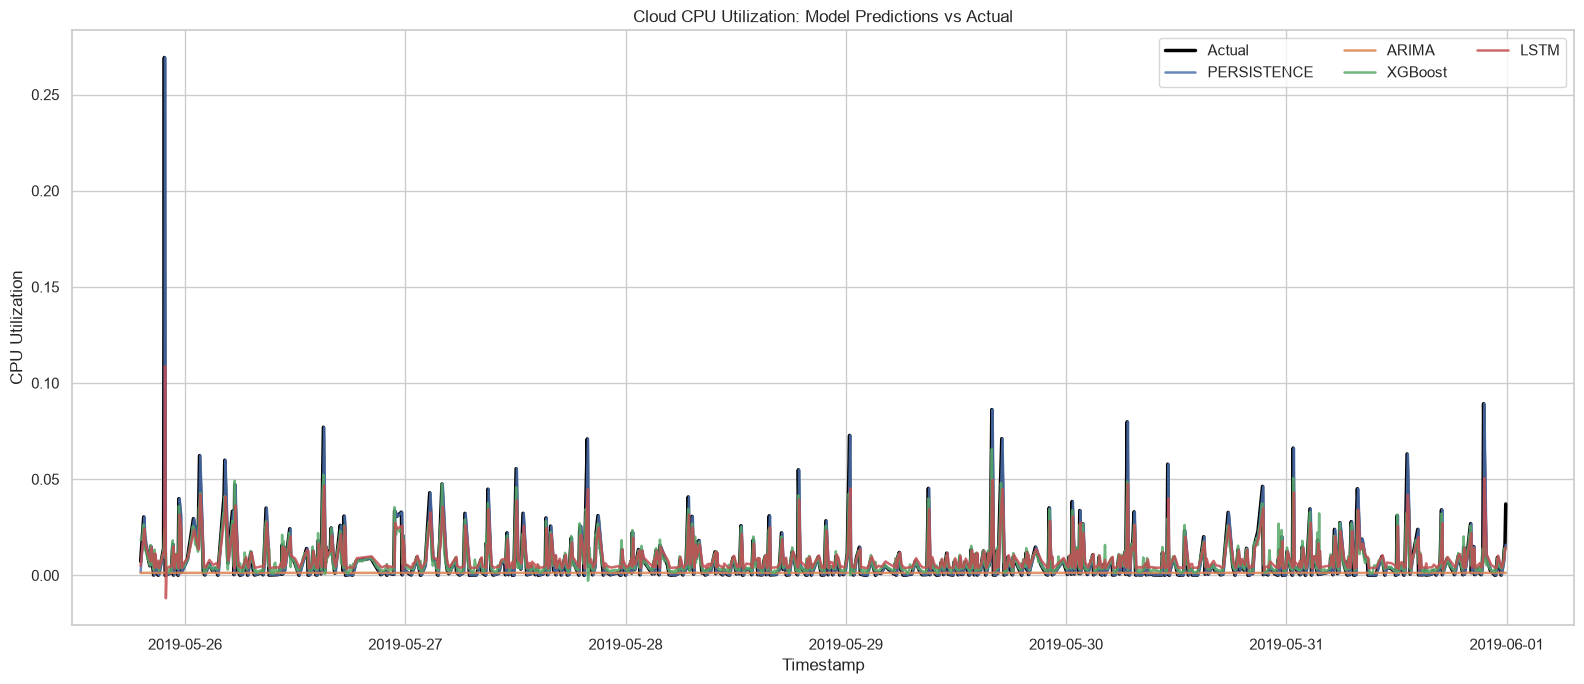

In [3]:
plt.figure(figsize=(16, 7))
plt.plot(merged['timestamp'], merged['actual'], label='Actual', color='black', linewidth=2.5)
for name in files:
    plt.plot(merged['timestamp'], merged[name], label=name.upper() if name != 'xgboost' else 'XGBoost', linewidth=1.8, alpha=0.85)
plt.title('Cloud CPU Utilization: Model Predictions vs Actual')
plt.xlabel('Timestamp')
plt.ylabel('CPU Utilization')
plt.legend(ncol=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_all_models_vs_actual.png', dpi=180)
plt.show()

merged.to_csv(OUTPUT_DIR / 'final_model_comparison.csv', index=False)

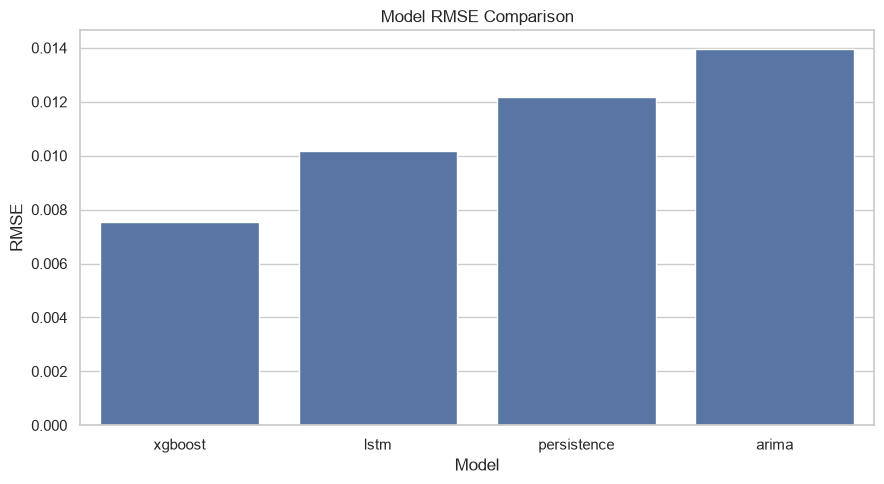

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x='model', y='RMSE')
plt.title('Model RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_rmse_comparison.png', dpi=160)
plt.show()